<a href="https://colab.research.google.com/github/diabateyoussouf/Daily-Data-Science/blob/main/dailly_02_dataset_house_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import les bibliothèques**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
from google.colab import files

#  Upload le fichier kaggle.json téléchargé depuis ton compte Kaggle
if not os.path.exists('/content/kaggle.json'):
    print("Sélectionne ton fichier kaggle.json :")
    uploaded = files.upload()

# Crée le dossier caché .kaggle requis par l'API et déplace le fichier
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Télécharge le dataset via son nom d'API unique
# Le nom du dataset est tiré de la fin de ton URL : juhibhojani/house-price
!kaggle datasets download -d juhibhojani/house-price

# Dézippe le fichier téléchargé automatiquement
import zipfile

with zipfile.ZipFile("house-price.zip", "r") as zip_ref:
    zip_ref.extractall("house_price_data")

Sélectionne ton fichier kaggle.json :


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/juhibhojani/house-price
License(s): Community Data License Agreement - Sharing - Version 1.0
100% 6.61M/6.61M [00:00<00:00, 82.2MB/s]



In [3]:
df = pd.read_csv('/content/house_price_data/house_prices.csv')

In [4]:
df.head(3)

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

# Objectif du Projet : Analyse et Prétraitement du Dataset House Price (Inde)

Prédire de manière précise le prix total des biens immobiliers (`Amount(in rupees)`) en nettoyant des données brutes issues du web (scraping), en gérant les formats monétaires complexes, et en préparant les features pour un modèle de Machine Learning de Régression.

---

##  Checklist d'Analyse

### 1. Analyse de Forme
* **Variable Cible (Target) :** `Amount(in rupees)` (object à traduire en valeur continue).
* **Nombre de Lignes et Colonnes :**  `(187531, 21)`.
* **Types de Variables :** Identification des types textuels (`object`) contenant des données numériques cachées, et des colonnes catégorielles (`location`, `Status`, `Transaction`, `facing`), les `int` et `float`.
* **Analyse des Valeurs Manquantes (NaN) :** `description`,`Price(in rupees)`,`Carpet Area`,`Status`,`Floor`,`Transaction`,`Furnishing`, `facing`,`overlooking`,`Society`,`Barthroom`,`Balcony`,`Car Parking`,`Ownership`,`Super Area`,`Dimenions`,`Plot Area`
* **Nettoyage des Unités et Doublons :** Détecter les colonnes qui expriment la même information sous des unités ou des angles différents (`Dimensions` vs `Plot Area`).

### 2. Analyse de Fond (Exploration pour la Régression)
* **Visualisation de la Target :** Tracer l'histogramme du prix pour vérifier l'asymétrie de la distribution (courbe à longue traîne ou *Skewness*).
* **Analyses Bivariées (Relation Features / Target) :**
    * *Hypothèse 1 :* La surface (`Carpet Area`) a une relation linéaire positive forte avec le prix.
    * *Hypothèse 2 :* La localisation (`location`) et le nombre de chambres (`BHK`) créent des variations de prix majeures à surface égale.
* **Analyses Multivariées :** Utilisation d'une matrice de corrélation de Spearman ou Pearson après le nettoyage numérique des colonnes clés.

---

##  3. Stratégie de Prétraitement des Données (Data Preprocessing)

###  Nettoyage Textuel et Conversion Numérique
* **Extraction et Conversion de la Cible (`Amount`) :** Convertir les chaînes textuelles comme `"42 Lac"` ($42 \\times 100\\,000$) et `"1.40 Cr"` ($1.4 \\times 10\\,000\\,000$) en valeurs numériques de roupies pures.
* **Nettoyage des Surfaces (`Carpet Area`) :** Supprimer la chaîne de caractères `" sqft"` et convertir la colonne en type `float`.
* **Extraction des Pièces (`BHK`) :** Extraire le nombre de chambres à partir du texte de la colonne `Title` (ex: `"2 BHK Ready..."` $\\rightarrow$ `2`).

###  Gestion des Valeurs Manquantes (NaN)
* **Seuil d'exclusion :** Supprimer les colonnes irrécupérables si leur taux de `NaN` dépasse $50\\%$.
* **Imputation stratégique :** Remplacer les `NaN` restants par la médiane par zone géographique (`location`) pour les surfaces.

###  Transformation Mathématique (Scaling & Log)
* **Log Transformation :** Appliquer $y\\_log = \\log(y)$ si la distribution du prix est fortement asymétrique afin d'aider les modèles de régression à converger efficacement.

---

## 4. Division des Données (Train / Test Split)
* **Séparation Features / Target :** Isoler la matrice $X$ et le vecteur cible $y$.
* **Découpage :** Séparation classique $80\\%$ Train / $20\\%$ Test.


# **1. Analyse de Forme**

* ## Variable Cible (Target)

In [6]:
print(df['Amount(in rupees)'].dtypes)

object


Chaque valeur contient de de valeur de prix et unité.

* ## Nombre de Lignes et Colonnes

In [7]:
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre de lignes : 187531
Nombre de colonnes : 21


* ## Types de Variables

In [8]:
df.dtypes

,0
Index,int64
Title,object
Description,object
Amount(in rupees),object
Price (in rupees),float64
location,object
Carpet Area,object
Status,object
Floor,object
Transaction,object


* ## Analyse des Valeurs Manquantes (NaN)

In [9]:
df.isna().sum()

,0
Index,0
Title,0
Description,3023
Amount(in rupees),0
Price (in rupees),17665
location,0
Carpet Area,80673
Status,615
Floor,7077
Transaction,83


* ## Nettoyage des Unités et Doublons

Doublons sur les lignes

In [10]:
print(df.duplicated().sum())

0


**Doublons sur les colonnes**

In [14]:
# Seuil à partir duquel on considère que deux colonnes sont quasiment identiques
SEUIL_SIMILITUDE = 0.95

print("ANALYSE DE LA REDONDANCE DES COLONNES...\n")
colonnes = df.columns
doublons_detectes = []

# Double boucle pour comparer chaque paire de colonnes unique
for i in range(len(colonnes)):
    for j in range(i + 1, len(colonnes)):
        col1 = colonnes[i]
        col2 = colonnes[j]

        # On calcule le pourcentage de lignes où col1 == col2 (en ignorant les NaN communs)
        # On remplace les NaN par un marqueur temporaire pour pouvoir les comparer
        similitude = (df[col1].astype(str) == df[col2].astype(str)).mean()

        if similitude >= SEUIL_SIMILITUDE:
            print(f"⚠️ Alerte Doublon : '{col1}' et '{col2}' sont similaires à {similitude*100:.2f}%")
            doublons_detectes.append((col1, col2, similitude))

if not doublons_detectes:
    print("✅ Aucune colonne n'est un doublon parfait (100% identique en texte brut).")

ANALYSE DE LA REDONDANCE DES COLONNES...

⚠️ Alerte Doublon : 'Dimensions' et 'Plot Area' sont similaires à 100.00%


On supprimera la colonne dimension à la suite et garder Plot Area

# **2. Analyse de Fond (Exploration pour la Régression)**

* ## Visualisation de la Target :
Tracer l'histogramme du prix pour vérifier l'asymétrie de la distribution (courbe à longue traîne ou Skewness).

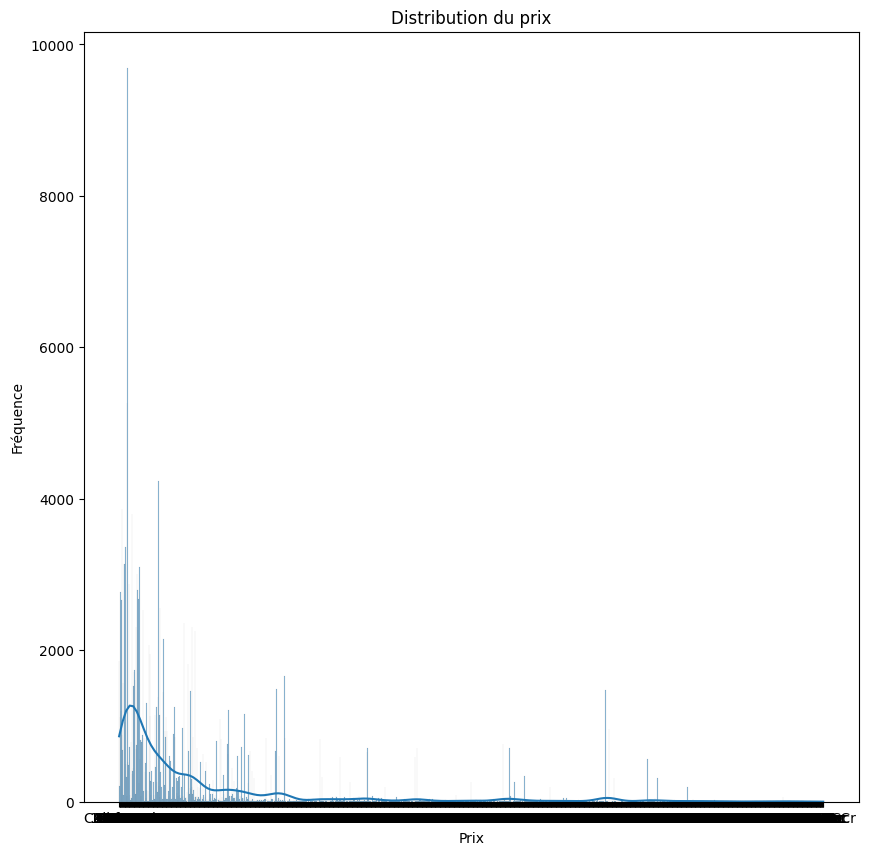

In [16]:
plt.figure(figsize=(10, 10))
sns.histplot(df['Amount(in rupees)'], kde=True)
plt.title('Distribution du prix')
plt.xlabel('Prix')
plt.ylabel('Fréquence')
plt.show()

*  ## Analyses Bivariées (Relation Features / Target) :

**Hypothèse 1 :** La surface (Carpet Area) a une relation linéaire positive forte avec le prix.

In [21]:
# Hypothèse 1 : La surface (Carpet Area) a une relation linéaire positive forte avec le prix.
df['Carpet Area'].head()

,Carpet Area
0,500 sqft
1,473 sqft
2,779 sqft
3,530 sqft
4,635 sqft


Il faut preprocessing afin de vérifier cette hypothèse.

# **3. Stratégie de Prétraitement des Données (Data Preprocessing) & Features ingenieres**


#### **Nettoyage Textuel et Conversion Numérique**

In [22]:
df_cp = df.copy()

* ##### **Extraction et Conversion de la Cible (Amount)**

La variable cible contient des valeurs montant avec son unité, c'est une valeur à traduire en valeurs continue.

In [23]:
df_cp['Amount(in rupees)'].head()

,Amount(in rupees)
0,42 Lac
1,98 Lac
2,1.40 Cr
3,25 Lac
4,1.60 Cr


Fonction d'extraction des informations

In [24]:
# Extraction
df_cp['val'] = df_cp['Amount(in rupees)'].str.extract('(\d+\.\d+|\d+)')
df_cp['unity'] = df_cp['Amount(in rupees)'].str.extract('(\D+)')

# Nettoyage  des espaces
df_cp['unity'] = df_cp['unity'].str.strip()

# Conversion de 'val' en float (les erreurs ou textes deviennent automatiquement NaN)
df_cp['val'] = pd.to_numeric(df_cp['val'], errors='coerce')

# Fonction de conversion mise à jour avec gestion du 'Call for Price' -> NaN
def convertir_en_roupies(row):
    valeur = row['val']
    unite = row['unity']

    # Si la valeur est manquante ou si c'est un "Call for Price", on retourne NaN
    if pd.isna(valeur) or unite == 'Call for Price':
        return np.nan

    # Application des multiplicateurs indiens
    if unite == 'Lac':
        return valeur * 100_000
    elif unite == 'Cr':
        return valeur * 10_000_000
    else:
        # Si c'est un nombre sans unité textuelle particulière
        return valeur

# Application de la fonction pour créer notre colonne finale
df_cp['prix_clean'] = df_cp.apply(convertir_en_roupies, axis=1)



<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1880/139332877.py:2: SyntaxWarning: invalid escape sequence '\d'
  df_cp['val'] = df_cp['Amount(in rupees)'].str.extract('(\d+\.\d+|\d+)')
/tmp/ipykernel_1880/139332877.py:3: SyntaxWarning: invalid escape sequence '\D'
  df_cp['unity'] = df_cp['Amount(in rupees)'].str.extract('(\D+)')


In [25]:
df_cp['prix_clean'].head()

,prix_clean
0,4200000.0
1,9800000.0
2,1.4
3,2500000.0
4,1.6


La repartition des diffrentes unité dans la col Amount

<Axes: ylabel='count'>

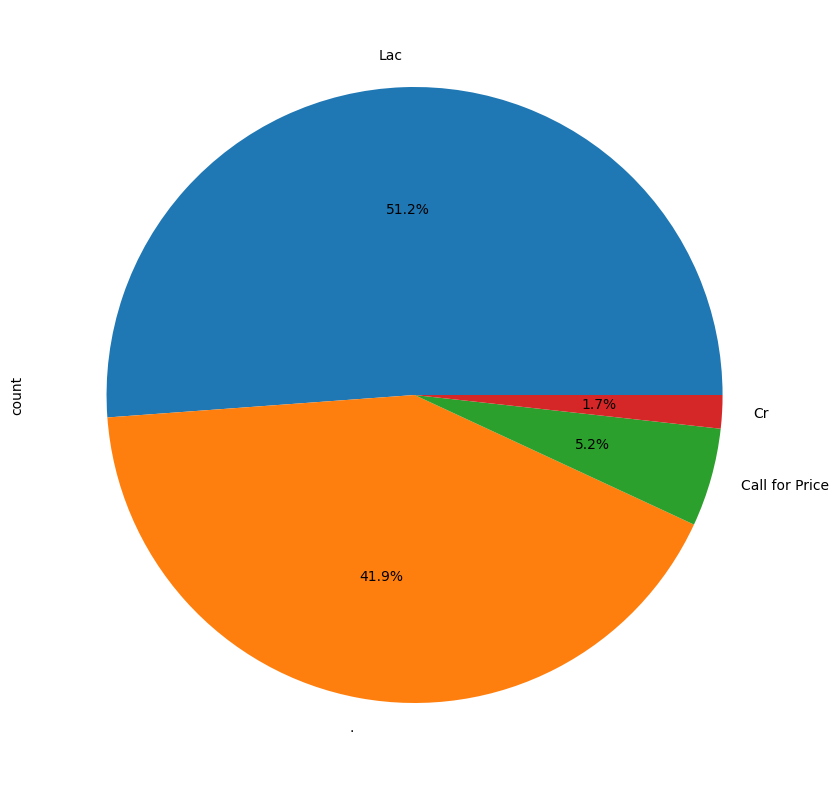

In [26]:
df_cp['unity'].value_counts().plot.pie(figsize=(10, 10), autopct='%1.1f%%')

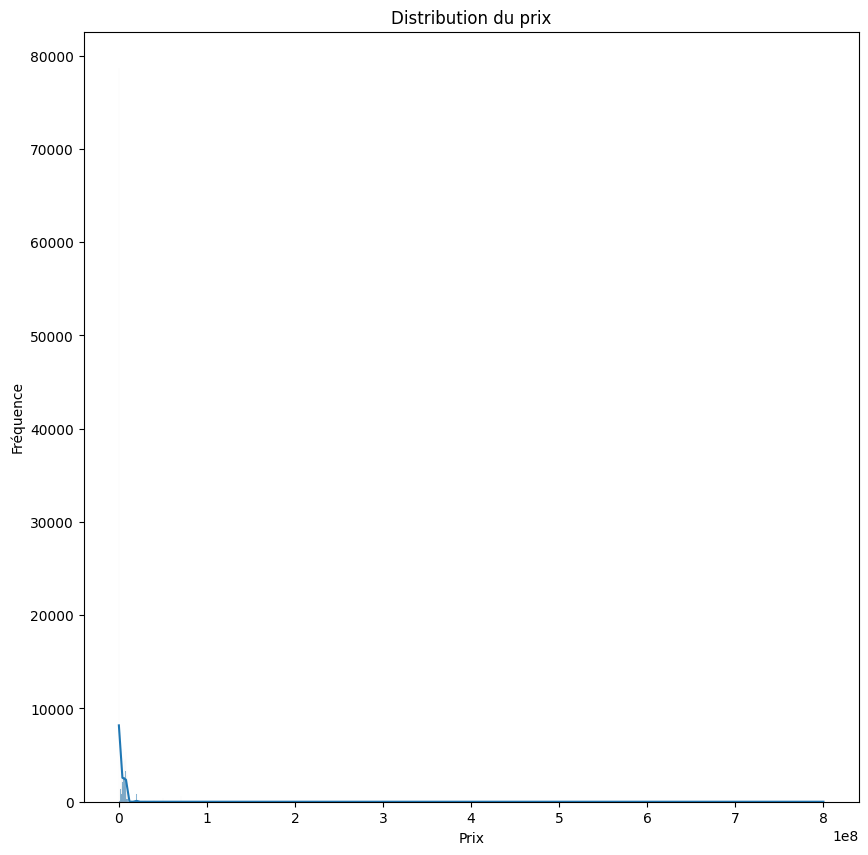

In [27]:
plt.figure(figsize=(10, 10))
sns.histplot(df_cp['prix_clean'], kde=True)
plt.title('Distribution du prix')
plt.xlabel('Prix')
plt.ylabel('Fréquence')
plt.show()

Suppression des col unitiles

In [ ]:
df_cp.drop(['Amount(in rupees)','val', 'unity'], axis=1, inplace=True)

In [82]:
df_cp.rename(columns={'prix_clean': 'Amount(in rupees)'}, inplace=True)

* ##### Suppression de la dimension car c'est une variable de redondance

In [86]:
df_cp.drop('Dimensions', axis=1, inplace=True)

* ##### **Nettoyage des Surfaces (Carpet Area)**

In [28]:
df_cp['Carpet Area'].head()

,Carpet Area
0,500 sqft
1,473 sqft
2,779 sqft
3,530 sqft
4,635 sqft


In [29]:
df_cp['Carpet Area'].unique()

array(['500 sqft', '473 sqft', '779 sqft', ..., '1634 sqft', '164 sqyrd',
       '136 sqft'], dtype=object)

Il y a deux unités ici. sqft et sqyrd (1 sqyrd = 9 sqft)

In [41]:
# Suppression des espaces
df_cp['Carpet Area'] = df_cp['Carpet Area'].str.strip()

# Extraction du nombre (gère les entiers et les décimaux)
df_cp['carpet_num'] = df_cp['Carpet Area'].str.extract('(\d+\.\d+|\d+)')
df_cp['carpet_num'] = pd.to_numeric(df_cp['carpet_num'], errors='coerce')

# Extraction de l'unité (on ne prend que les lettres pour éviter les résidus de caractères)
df_cp['carpet_unit'] = df_cp['Carpet Area'].str.extract('([a-zA-Z]+)')
df_cp['carpet_unit'] = df_cp['carpet_unit'].str.lower().str.strip()

# Dictionnaire des coefficients de conversion vers le SQFT
facteurs_conversion = {
    'sqft': 1.0,
    'sqyrd': 9.0,
    'sqm': 10.7639,
    'acre': 43560.0,
    'ground': 2400.0,
    'cent': 435.6,
    'bigha': 27000.0,
    'marla': 272.25,
    'kanal': 5445.0
}

# Fonction de conversion mise à jour
def convertir_surface(row):
    valeur = row['carpet_num']
    unite = row['carpet_unit']

    if pd.isna(valeur):
        return np.nan

    # On cherche le coefficient dans notre dictionnaire
    # Si l'unité est inconnue ou NaN, .get() renvoie 1.0 par défaut (on suppose que c'est du sqft)
    coeff = facteurs_conversion.get(unite, 1.0)

    return valeur * coeff

#  Application du calcul et nettoyage
df_cp['carpet_area_clean'] = df_cp.apply(convertir_surface, axis=1)

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1880/1868047653.py:5: SyntaxWarning: invalid escape sequence '\d'
  df_cp['carpet_num'] = df_cp['Carpet Area'].str.extract('(\d+\.\d+|\d+)')


In [42]:
df_cp['carpet_area_clean'].head()

,carpet_area_clean
0,500.0
1,473.0
2,779.0
3,530.0
4,635.0


In [44]:
df_cp['carpet_area_clean'].isna().sum()

np.int64(80673)

La repartition des unités de surfaces

<Axes: ylabel='count'>

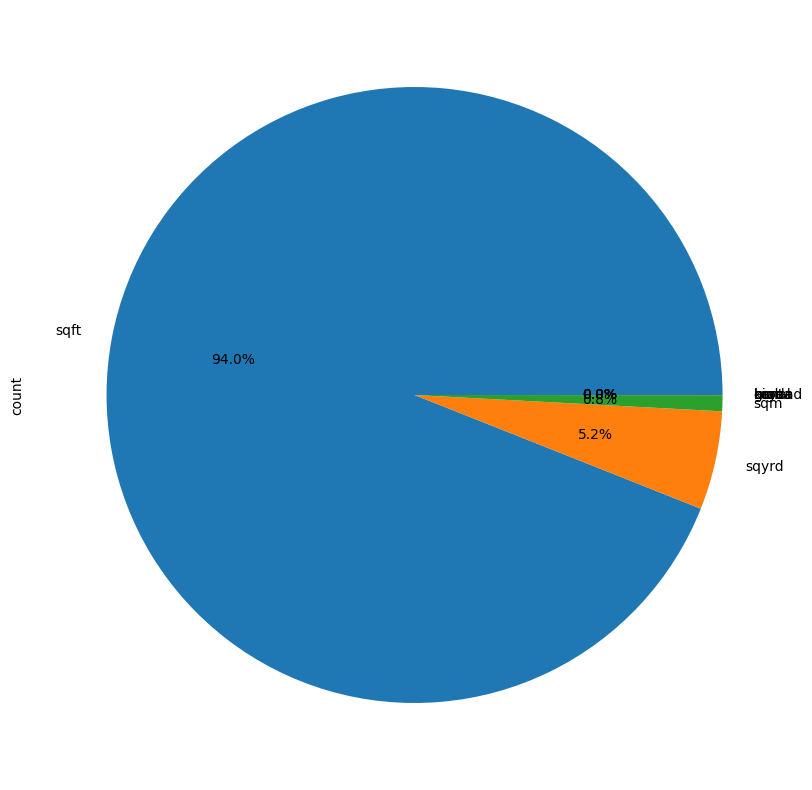

In [43]:
df_cp['carpet_unit'].value_counts().plot.pie(figsize=(10, 10), autopct='%1.1f%%')

Suppression des colonnes temp

In [67]:
df_cp.drop(['Carpet Area','carpet_num', 'carpet_unit'], axis=1, inplace=True)

In [130]:
df_cp.rename(columns={'carpet_area_clean': 'Carpet Area'}, inplace=True)

* ##### **Extraction des Pièces (BHK)**

In [45]:
df_cp['Title'].head()

,Title
0,1 BHK Ready to Occupy Flat for sale in Srushti...
1,2 BHK Ready to Occupy Flat for sale in Dosti V...
2,2 BHK Ready to Occupy Flat for sale in Sunrise...
3,1 BHK Ready to Occupy Flat for sale Kasheli
4,2 BHK Ready to Occupy Flat for sale in TenX Ha...


In [47]:
df_cp['Title'] = df_cp['Title'].str.strip()
df_cp['BHK'] = df_cp['Title'].str.extract('(\d+)')

df_cp['BHK'] = pd.to_numeric(df_cp['BHK'], errors='coerce')

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1880/2633931026.py:2: SyntaxWarning: invalid escape sequence '\d'
  df_cp['BHK'] = df_cp['Title'].str.extract('(\d+)')


In [50]:
df_cp['BHK'].head()

,BHK
0,1.0
1,2.0
2,2.0
3,1.0
4,2.0


In [51]:
df_cp['BHK'].isna().sum()

np.int64(854)

Suppresion de col Title

In [68]:
df_cp.drop('Title', axis=1, inplace=True)

* ##### **Description**

In [53]:
df_cp['Description'].head()

,Description
0,"Bhiwandi, Thane has an attractive 1 BHK Flat f..."
1,One can find this stunning 2 BHK flat for sale...
2,Up for immediate sale is a 2 BHK apartment in ...
3,This beautiful 1 BHK Flat is available for sal...
4,"This lovely 2 BHK Flat in Pokhran Road, Thane ..."


C'est pas la peine cette colonne sert à rien car on a dejà extraire ces informations dans title

In [69]:
df_cp.drop('Description', axis=1, inplace=True)

* ##### **location Extraction des informations**

In [70]:
df_cp['location'].head()

,location
0,thane
1,thane
2,thane
3,thane
4,thane


In [71]:
df_cp['location'] = df_cp['location'].str.strip()
df_cp['location'] = df_cp['location'].str.lower()

In [72]:
df_cp['location'].unique()

array(['thane', 'navi-mumbai', 'nagpur', 'mumbai', 'ahmedabad',
       'bangalore', 'chennai', 'gurgaon', 'hyderabad', 'indore', 'jaipur',
       'kolkata', 'lucknow', 'new-delhi', 'noida', 'pune', 'agra',
       'ahmadnagar', 'allahabad', 'aurangabad', 'badlapur', 'belgaum',
       'bhiwadi', 'bhiwandi', 'bhopal', 'bhubaneswar', 'chandigarh',
       'coimbatore', 'dehradun', 'durgapur', 'ernakulam', 'faridabad',
       'ghaziabad', 'goa', 'greater-noida', 'guntur', 'guwahati',
       'gwalior', 'haridwar', 'jabalpur', 'jamshedpur', 'jodhpur',
       'kalyan', 'kanpur', 'kochi', 'kozhikode', 'ludhiana', 'madurai',
       'mangalore', 'mohali', 'mysore', 'nashik', 'navsari', 'nellore',
       'palakkad', 'palghar', 'panchkula', 'patna', 'pondicherry',
       'raipur', 'rajahmundry', 'ranchi', 'satara', 'shimla', 'siliguri',
       'solapur', 'sonipat', 'surat', 'thrissur', 'tirupati', 'trichy',
       'trivandrum', 'udaipur', 'udupi', 'vadodara', 'vapi', 'varanasi',
       'vijayawada',

La colonne à garder

<Axes: ylabel='count'>

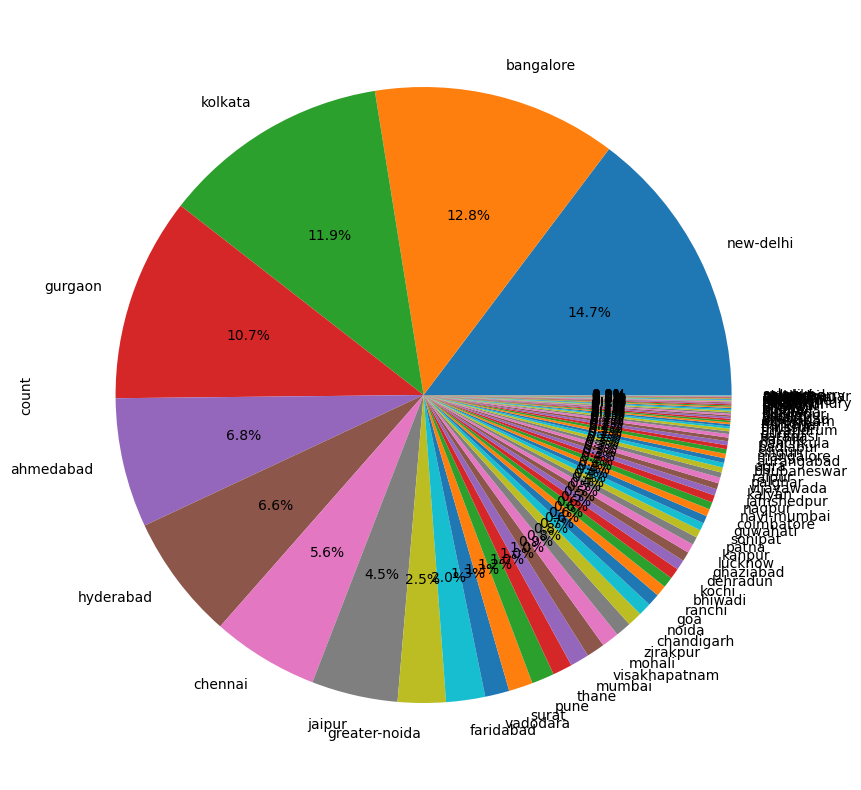

In [74]:
df_cp['location'].value_counts().plot.pie(figsize=(10, 10), autopct='%1.1f%%')

* ##### **Status**

In [64]:
df_cp['Status'].unique()

array(['Ready to Move', nan], dtype=object)

<Axes: ylabel='count'>

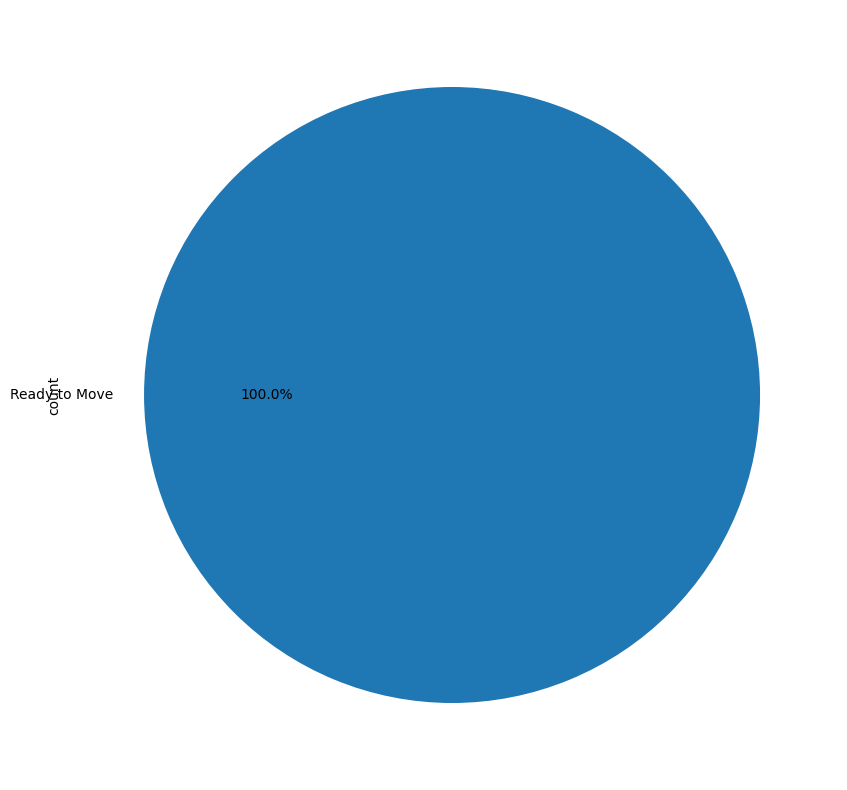

In [65]:
df_cp['Status'].value_counts().plot.pie(figsize=(10, 10), autopct='%1.1f%%')

Nous allons supprimer cette valeur car ça contient accune information utile pour notre modèle( ne varie pas).

In [66]:
df_cp.drop('Status', axis=1, inplace=True)

**Supprimer index**

In [79]:
df_cp.drop('Index', axis=1, inplace=True)

* ##### **La transaction**

In [89]:
df_cp['Transaction'].unique()

array(['Resale', 'New Property', nan, 'Other', 'Rent/Lease'], dtype=object)

In [90]:
# Supprimer les lignes de location (Rent/Lease) pour ne garder que la vente
df_cp = df_cp[df_cp['Transaction'] != 'Rent/Lease'].copy()

# Remplacer les valeurs manquantes (NaN) ou 'Other' par 'Inconnu' pour ne pas perdre les lignes
df_cp['Transaction'] = df_cp['Transaction'].fillna('Inconnu')
df_cp['Transaction'] = df_cp['Transaction'].replace('Other', 'Inconnu')

In [93]:
print("Lignes de location supprimées et valeurs aberrantes nettoyées !")
print("Répartition finale de la colonne Transaction :")
print(df_cp['Transaction'].value_counts())

Lignes de location supprimées et valeurs aberrantes nettoyées !
Répartition finale de la colonne Transaction :
Transaction
Resale          144172
New Property     42565
Inconnu            792
Name: count, dtype: int64


<Axes: ylabel='count'>

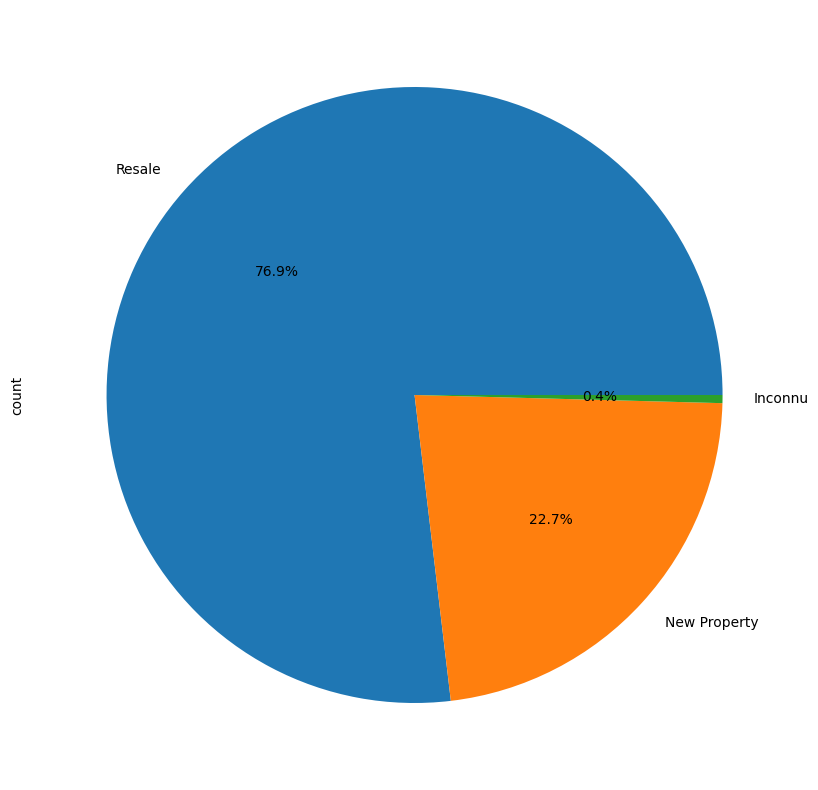

In [92]:
df_cp['Transaction'].value_counts().plot.pie(figsize=(10, 10), autopct='%1.1f%%')

**A garder pour l'instant**

* ##### **Furnishing**

In [97]:
df_cp['Furnishing'].unique()

array(['Unfurnished', 'Semi-Furnished', 'Furnished', nan], dtype=object)

<Axes: ylabel='count'>

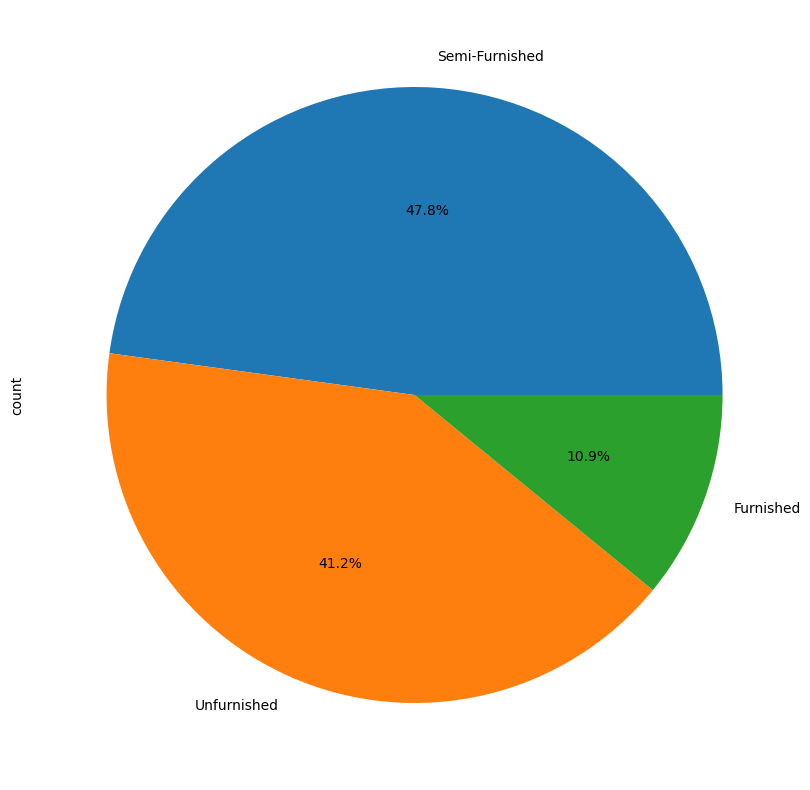

In [98]:
df_cp['Furnishing'].value_counts().plot.pie(figsize=(10, 10), autopct='%1.1f%%')

In [99]:
# Remplacer les valeurs manquantes (NaN) par 'Unknown'
df_cp['Furnishing'] = df_cp['Furnishing'].fillna('Unknown')

# Créer le dictionnaire de correspondance (Mapping ordinal)
# On donne une valeur numérique plus élevée aux biens meublés
furnishing_mapping = {
    'Unfurnished': 0,
    'Semi-Furnished': 1,
    'Furnished': 2,
    'Unknown': -1  # On met -1 pour les inconnus afin que le modèle les distingue du vide complet
}

# Application du mapping pour créer la version numérique
df_cp['furnishing_clean'] = df_cp['Furnishing'].map(furnishing_mapping)

# Suppression de l'ancienne colonne textuelle
df_cp = df_cp.drop(columns=['Furnishing'])

print("Colonne 'Furnishing' encodée avec succès en valeurs numériques ordonnées !")
print(df_cp['furnishing_clean'].value_counts())

Colonne 'Furnishing' encodée avec succès en valeurs numériques ordonnées !
furnishing_clean
 1    88316
 0    76154
 2    20162
-1     2897
Name: count, dtype: int64


In [100]:
df_cp.rename(columns={'furnishing_clean': 'Furnishing'}, inplace=True)

* ##### **Floor**

In [103]:
# Remplacement préventif des termes textuels par des chiffres
df_cp['Floor'] = df_cp['Floor'].str.lower().str.strip()
df_cp['Floor'] = df_cp['Floor'].str.replace('ground', '0')

# Extraction du numéro de l'étage (le premier groupe de chiffres)
df_cp['etage_bien'] = df_cp['Floor'].str.extract('^(\d+)')

# Extraction du nombre total d'étages (le chiffre qui vient après "out of")
df_cp['total_etages'] = df_cp['Floor'].str.extract('out of\s*(\d+)')

# Conversion des deux nouvelles colonnes en type numérique
df_cp['etage_bien'] = pd.to_numeric(df_cp['etage_bien'], errors='coerce')
df_cp['total_etages'] = pd.to_numeric(df_cp['total_etages'], errors='coerce')

# Suppression de l'ancienne colonne 'Floor' textuelle
df_cp = df_cp.drop(columns=['Floor'])

print(" Colonne 'Floor' séparée avec succès en deux features numériques !")
print(df_cp[['etage_bien', 'total_etages']].head(10))

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1880/3301745493.py:6: SyntaxWarning: invalid escape sequence '\d'
  df_cp['etage_bien'] = df_cp['Floor'].str.extract('^(\d+)')
/tmp/ipykernel_1880/3301745493.py:9: SyntaxWarning: invalid escape sequence '\s'
  df_cp['total_etages'] = df_cp['Floor'].str.extract('out of\s*(\d+)')


 Colonne 'Floor' séparée avec succès en deux features numériques !
   etage_bien  total_etages
0        10.0          11.0
1         3.0          22.0
2        10.0          29.0
3         1.0           3.0
4        20.0          42.0
5         2.0           7.0
6         4.0           5.0
7         0.0           7.0
8         0.0           2.0
9         3.0          27.0


In [106]:
df_cp['etage_bien'].head()

,etage_bien
0,10.0
1,3.0
2,10.0
3,1.0
4,20.0


In [105]:
df_cp['total_etages'].head()

,total_etages
0,11.0
1,22.0
2,29.0
3,3.0
4,42.0


* ##### **Facing**

In [109]:
# Remplacer les valeurs manquantes par 'Inconnu'
df_cp['facing'] = df_cp['facing'].fillna('Inconnu')

# Nettoyer les espaces s'il y en a
df_cp['facing'] = df_cp['facing'].str.strip()

print("Colonne 'facing' sauvée et nettoyée !")
print(df_cp['facing'].value_counts())

Colonne 'facing' sauvée et nettoyée !
facing
Inconnu         70233
East            54741
North - East    24219
North           16533
West             8574
South            4693
North - West     3843
South - East     2622
South -West      2071
Name: count, dtype: int64


* ##### **Overlooking**

In [113]:
# On force tout le texte en minuscules et on remplace les NaN par du vide pour éviter les erreurs
df_cp['overlooking'] = df_cp['overlooking'].astype(str).str.lower()

# On crée nos 3 colonnes de caractéristiques (0 ou 1) en cherchant les mots-clés
df_cp['vue_parc'] = df_cp['overlooking'].str.contains('garden/park').astype(int)
df_cp['vue_route'] = df_cp['overlooking'].str.contains('main road').astype(int)
df_cp['vue_piscine'] = df_cp['overlooking'].str.contains('pool').astype(int)

# Suppression de l'ancienne colonne complexe
df_cp = df_cp.drop(columns=['overlooking'])

print(" Colonne 'overlooking' découpée avec succès en 3 indicateurs binaires !")
print(df_cp[['vue_parc', 'vue_route', 'vue_piscine']].head(10))

 Colonne 'overlooking' découpée avec succès en 3 indicateurs binaires !
   vue_parc  vue_route  vue_piscine
0         0          0            0
1         1          0            0
2         1          0            0
3         0          0            0
4         1          1            0
5         1          1            0
6         0          0            0
7         0          0            0
8         0          0            0
9         1          0            0


In [116]:
df_cp['Society'].head()

,Society
0,Srushti Siddhi Mangal Murti Complex
1,Dosti Vihar
2,Sunrise by Kalpataru
3,NaN
4,TenX Habitat Raymond Realty


In [117]:
#  Remplacer les NaN par 'Inconnu'
df_cp['Society'] = df_cp['Society'].fillna('Inconnu')

# Calculer la fréquence d'apparition de chaque résidence
frequences = df_cp['Society'].value_counts()

# Remplacer le nom par sa fréquence
df_cp['society_freq'] = df_cp['Society'].map(frequences)

# Suppression de l'ancienne colonne textuelle
df_cp = df_cp.drop(columns=['Society'])

print(" Colonne 'Society' transformée en fréquences numériques !")
print(df_cp[['society_freq']].head(10))

 Colonne 'Society' transformée en fréquences numériques !
   society_freq
0             1
1             1
2             6
3        109676
4             6
5             2
6        109676
7        109676
8        109676
9             4


In [118]:
df_cp.rename(columns={'society_freq': 'Society'}, inplace=True)

In [122]:
#  Remplacer le texte '> 10' par la valeur numérique 11
df_cp['Bathroom'] = df_cp['Bathroom'].replace('> 10', '11')

# Convertir la colonne en numérique (les NaN restent des NaN pour l'instant)
df_cp['Bathroom'] = pd.to_numeric(df_cp['Bathroom'], errors='coerce')

# Calculer la médiane de la colonne (ex: souvent 2 dans l'immobilier)
mediane_bathroom = df_cp['Bathroom'].median()

#  Remplacer les valeurs manquantes (NaN) par cette médiane
df_cp['Bathroom'] = df_cp['Bathroom'].fillna(mediane_bathroom)

# Forcer le type en entier (int) puisqu'on ne peut pas avoir 1.5 salle de bain
df_cp['Bathroom'] = df_cp['Bathroom'].astype(int)

print(f"Colonne 'Bathroom' convertie avec succès ! (Médiane appliquée : {mediane_bathroom})")
print(df_cp['Bathroom'].value_counts())

Colonne 'Bathroom' convertie avec succès ! (Médiane appliquée : 2.0)
Bathroom
2     93834
3     55780
1     18654
4     15600
5      3343
6       209
7        35
11       35
10       14
8        14
9        11
Name: count, dtype: int64


In [125]:
# Remplacer le texte '> 10' par la valeur numérique 11
df_cp['Balcony'] = df_cp['Balcony'].replace('> 10', '11')

# Convertir la colonne en numérique
df_cp['Balcony'] = pd.to_numeric(df_cp['Balcony'], errors='coerce')

# Calculer la médiane de la colonne
mediane_balcony = df_cp['Balcony'].median()

# Remplacer les valeurs manquantes (NaN) par cette médiane
df_cp['Balcony'] = df_cp['Balcony'].fillna(mediane_balcony)

# Forcer le type en entier (int)
df_cp['Balcony'] = df_cp['Balcony'].astype(int)

print(f"Colonne 'Balcony' convertie avec succès ! (Médiane appliquée : {mediane_balcony})")
print(df_cp['Balcony'].value_counts())

Colonne 'Balcony' convertie avec succès ! (Médiane appliquée : 2.0)
Balcony
2     100743
1      49218
3      27111
4       9420
5        841
6        132
11        22
7         14
10        13
8         13
9          2
Name: count, dtype: int64


In [128]:
#  On force le texte en minuscules et on nettoie les espaces
df_cp['Car Parking'] = df_cp['Car Parking'].astype(str).str.lower().str.strip()

# Extraction du nombre de places (le premier chiffre trouvé)
df_cp['parking_spaces'] = df_cp['Car Parking'].str.extract('(\d+)')
df_cp['parking_spaces'] = pd.to_numeric(df_cp['parking_spaces'], errors='coerce').fillna(0).astype(int)

# Extraction du type de parking (open ou covered)
def determiner_type_parking(text):
    if 'covered' in text:
        return 'Covered'
    elif 'open' in text:
        return 'Open'
    else:
        return 'None'  # Pour les anciens NaN ou valeurs bizarres

df_cp['parking_type'] = df_cp['Car Parking'].apply(determiner_type_parking)

# Suppression de l'ancienne colonne textuelle
df_cp = df_cp.drop(columns=['Car Parking'])

print(" Colonne 'Car Parking' transformée avec succès !")
print(df_cp[['parking_spaces', 'parking_type']].head(10))

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1880/3919808492.py:5: SyntaxWarning: invalid escape sequence '\d'
  df_cp['parking_spaces'] = df_cp['Car Parking'].str.extract('(\d+)')


 Colonne 'Car Parking' transformée avec succès !
   parking_spaces parking_type
0               0         None
1               1         Open
2               1      Covered
3               0         None
4               1      Covered
5               0         None
6               0         None
7               0         None
8               0         None
9               1      Covered


In [134]:
df_cp.dtypes

,0
Price (in rupees),float64
location,object
Transaction,object
facing,object
Bathroom,int64
Balcony,int64
Ownership,object
Super Area,object
Plot Area,float64
Amount(in rupees),float64


In [136]:
import pandas as pd
import numpy as np

# Sécurité anti-KeyError : On vérifie si la colonne existe avant de lancer le traitement
if 'Car Parking' in df_cp.columns:

    # 1. Nettoyage en gardant les vrais NaN intacts
    df_cp['Car Parking'] = df_cp['Car Parking'].str.lower().str.strip()

    # 2. Extraction du nombre de places (Le 'r' supprime le SyntaxWarning)
    df_cp['parking_spaces'] = df_cp['Car Parking'].str.extract(r'(\d+)')
    df_cp['parking_spaces'] = pd.to_numeric(df_cp['parking_spaces'], errors='coerce').fillna(0).astype(int)

    # 3. Extraction du type de parking
    def determiner_type_parking(valeur):
        if pd.isna(valeur):
            return 'None'

        if 'covered' in valeur:
            return 'Covered'
        elif 'open' in valeur:
            return 'Open'
        else:
            return 'None'

    # Application de la fonction
    df_cp['parking_type'] = df_cp['Car Parking'].apply(determiner_type_parking)

    # 4. Suppression de l'ancienne colonne textuelle
    df_cp = df_cp.drop(columns=['Car Parking'])
    print("✅ Colonne 'Car Parking' transformée avec succès de manière 100% robuste !")

else:
    print("⚠️ La colonne 'Car Parking' a déjà été supprimée et transformée lors d'une exécution précédente.")

# Affichage du résultat (fonctionne dans tous les cas)
print(df_cp[['parking_spaces', 'parking_type']].head(10))

⚠️ La colonne 'Car Parking' a déjà été supprimée et transformée lors d'une exécution précédente.
   parking_spaces parking_type
0               0         None
1               1         Open
2               1      Covered
3               0         None
4               1      Covered
5               0         None
6               0         None
7               0         None
8               0         None
9               1      Covered


In [140]:
# On réutilise le dictionnaire de conversion que l'on a validé ensemble au début
facteurs_conversion = {
    'sqft': 1.0, 'sqyrd': 9.0, 'sqm': 10.7639, 'acre': 43560.0,
    'ground': 2400.0, 'cent': 435.6, 'bigha': 27000.0, 'marla': 272.25, 'kanal': 5445.0
}

# Extraction et conversion de 'Super Area' en SQFT
df_cp['Super Area'] = df_cp['Super Area'].astype(str).str.strip().str.lower()

# Extraction du nombre et de l'unité
df_cp['super_num'] = df_cp['Super Area'].str.extract(r'(\d+\.\d+|\d+)')
df_cp['super_num'] = pd.to_numeric(df_cp['super_num'], errors='coerce')
df_cp['super_unit'] = df_cp['Super Area'].str.extract(r'([a-zA-Z]+)')

def convertir_super(row):
    valeur = row['super_num']
    unite = row['super_unit']
    if pd.isna(valeur):
        return np.nan
    coeff = facteurs_conversion.get(unite, 1.0)
    return valeur * coeff

df_cp['super_area_clean'] = df_cp.apply(convertir_super, axis=1)

# fusion magique : On crée 'surface_finale_sqft'
# Si carpet_area_clean est NaN, on prend super_area_clean. Sinon on garde carpet_area_clean.
df_cp['surface_finale_sqft'] = df_cp['Carpet Area'].fillna(df_cp['super_area_clean'])

# Remplissage des derniers NaN par la médiane générale pour ne perdre aucune ligne
mediane_surface = df_cp['surface_finale_sqft'].median()
df_cp['surface_finale_sqft'] = df_cp['surface_finale_sqft'].fillna(mediane_surface)

# Nettoyage des colonnes temporaires et anciennes
colonnes_a_supprimer = ['Super Area', 'super_num', 'super_unit', 'super_area_clean', 'Carpet Area']
# Sécurité pour ne pas crasher si certaines colonnes ont déjà été supprimées
colonnes_a_supprimer = [col for col in colonnes_a_supprimer if col in df_cp.columns]
df_cp = df_cp.drop(columns=colonnes_a_supprimer)

print(" Colonne 'Super Area' traitée et fusionnée dans 'surface_finale_sqft' !")
print(df_cp[['surface_finale_sqft']].head(10))

 Colonne 'Super Area' traitée et fusionnée dans 'surface_finale_sqft' !
   surface_finale_sqft
0                500.0
1                473.0
2                779.0
3                530.0
4                635.0
5                680.0
6                550.0
7                575.0
8                600.0
9                900.0


In [141]:
df_cp.dtypes

,0
Price (in rupees),float64
location,object
Transaction,object
facing,object
Bathroom,int64
Balcony,int64
Ownership,object
Plot Area,float64
Amount(in rupees),float64
BHK,float64


In [142]:
df_cp.head()

,Price (in rupees),location,Transaction,facing,Bathroom,Balcony,Ownership,Plot Area,Amount(in rupees),BHK,Furnishing,etage_bien,total_etages,vue_parc,vue_route,vue_piscine,Society,parking_spaces,parking_type,surface_finale_sqft
0,6000.0,thane,Resale,Inconnu,1,2,NaN,NaN,4200000.0,1.0,0,10.0,11.0,0,0,0,1,0,None,500.0
1,13799.0,thane,Resale,East,2,2,Freehold,NaN,9800000.0,2.0,1,3.0,22.0,1,0,0,1,1,Open,473.0
2,17500.0,thane,Resale,East,2,2,Freehold,NaN,1.4,2.0,0,10.0,29.0,1,0,0,6,1,Covered,779.0
3,NaN,thane,Resale,Inconnu,1,1,NaN,NaN,2500000.0,1.0,0,1.0,3.0,0,0,0,109676,0,None,530.0
4,18824.0,thane,Resale,West,2,2,Co-operative Society,NaN,1.6,2.0,0,20.0,42.0,1,1,0,6,1,Covered,635.0


In [143]:
import pandas as pd

# 1. Liste des colonnes textuelles restantes à encoder
colonnes_categoriques = ['location', 'Transaction', 'facing', 'parking_type']

# 2. Application du One-Hot Encoding magique de Pandas
# drop_first=True permet d'éviter le piège de la colinéarité en supprimant une colonne redondante
df_final = pd.get_dummies(df_cp, columns=colonnes_categoriques, drop_first=True, dtype=int)

print("🚀 Encodage terminé ! Toutes les colonnes textuelles ont été converties en 0 et 1.")
print(f"Nouvelle forme du dataset : {df_final.shape[0]} lignes et {df_final.shape[1]} colonnes.")

🚀 Encodage terminé ! Toutes les colonnes textuelles ont été converties en 0 et 1.
Nouvelle forme du dataset : 187529 lignes et 108 colonnes.


In [144]:
df_cp.head()

,Price (in rupees),location,Transaction,facing,Bathroom,Balcony,Ownership,Plot Area,Amount(in rupees),BHK,Furnishing,etage_bien,total_etages,vue_parc,vue_route,vue_piscine,Society,parking_spaces,parking_type,surface_finale_sqft
0,6000.0,thane,Resale,Inconnu,1,2,NaN,NaN,4200000.0,1.0,0,10.0,11.0,0,0,0,1,0,None,500.0
1,13799.0,thane,Resale,East,2,2,Freehold,NaN,9800000.0,2.0,1,3.0,22.0,1,0,0,1,1,Open,473.0
2,17500.0,thane,Resale,East,2,2,Freehold,NaN,1.4,2.0,0,10.0,29.0,1,0,0,6,1,Covered,779.0
3,NaN,thane,Resale,Inconnu,1,1,NaN,NaN,2500000.0,1.0,0,1.0,3.0,0,0,0,109676,0,None,530.0
4,18824.0,thane,Resale,West,2,2,Co-operative Society,NaN,1.6,2.0,0,20.0,42.0,1,1,0,6,1,Covered,635.0


In [145]:
# 1. On renomme la vraie colonne de prix et on supprime les colonnes inutiles / doublons
if 'Amount(in rupees)' in df_cp.columns:
    df_cp['prix_final'] = df_cp['Amount(in rupees)']

colonnes_suicide = ['Price (in rupees)', 'Amount(in rupees)', 'Plot Area']
colonnes_a_retirer = [col for col in colonnes_suicide if col in df_cp.columns]
df_cp = df_cp.drop(columns=colonnes_a_retirer)

# 2. Nettoyage rapide de la colonne Ownership
df_cp['Ownership'] = df_cp['Ownership'].fillna('Inconnu')

# 3. Liste de TOUTES les colonnes textuelles à encoder en 0 et 1
colonnes_categoriques = ['location', 'Transaction', 'facing', 'parking_type', 'Ownership']

# 4. Encodage magique (One-Hot Encoding)
# drop_first=True évite les répétitions mathématiques pour l'algorithme
df_final = pd.get_dummies(df_cp, columns=colonnes_categoriques, drop_first=True, dtype=int)

print("🚀 Étape franchie avec succès !")
print(f"Le dataset final contient désormais {df_final.shape[1]} colonnes (toutes numériques !).")
print("\nVoici les premières lignes prêtes pour le Machine Learning :")
print(df_final[['prix_final', 'surface_finale_sqft', 'BHK']].head())

🚀 Étape franchie avec succès !
Le dataset final contient désormais 109 colonnes (toutes numériques !).

Voici les premières lignes prêtes pour le Machine Learning :
   prix_final  surface_finale_sqft  BHK
0   4200000.0                500.0  1.0
1   9800000.0                473.0  2.0
2         1.4                779.0  2.0
3   2500000.0                530.0  1.0
4         1.6                635.0  2.0


In [147]:
df_cp.head()

,location,Transaction,facing,Bathroom,Balcony,Ownership,BHK,Furnishing,etage_bien,total_etages,vue_parc,vue_route,vue_piscine,Society,parking_spaces,parking_type,surface_finale_sqft,prix_final
0,thane,Resale,Inconnu,1,2,Inconnu,1.0,0,10.0,11.0,0,0,0,1,0,None,500.0,4200000.0
1,thane,Resale,East,2,2,Freehold,2.0,1,3.0,22.0,1,0,0,1,1,Open,473.0,9800000.0
2,thane,Resale,East,2,2,Freehold,2.0,0,10.0,29.0,1,0,0,6,1,Covered,779.0,1.4
3,thane,Resale,Inconnu,1,1,Inconnu,1.0,0,1.0,3.0,0,0,0,109676,0,None,530.0,2500000.0
4,thane,Resale,West,2,2,Co-operative Society,2.0,0,20.0,42.0,1,1,0,6,1,Covered,635.0,1.6


In [148]:
import pandas as pd
import numpy as np

# 1. Standardisation des prix (Conversion des Crores cachés en Roupies)
def corriger_crores(prix):
    if prix < 100:  # Un prix en roupies ne peut pas être inférieur à 100, c'est forcément un Crore (ex: 1.4)
        return prix * 10000000
    return prix

df_cp['prix_final'] = df_cp['prix_final'].apply(corriger_crores)

# 2. Liste des colonnes textuelles à encoder en 0 et 1
colonnes_categoriques = ['location', 'Transaction', 'facing', 'parking_type', 'Ownership']

# 3. Application du One-Hot Encoding (get_dummies)
df_final = pd.get_dummies(df_cp, columns=colonnes_categoriques, drop_first=True, dtype=int)

print("🏆 TOUT EST PARFAIT ! Le dataset est 100% prêt pour le Machine Learning.")
print(f"Forme finale du dataset : {df_final.shape[0]} lignes et {df_final.shape[1]} colonnes.")
print("\nAperçu des prix corrigés (en roupies brutes) :")
print(df_final['prix_final'].head())

🏆 TOUT EST PARFAIT ! Le dataset est 100% prêt pour le Machine Learning.
Forme finale du dataset : 187529 lignes et 109 colonnes.

Aperçu des prix corrigés (en roupies brutes) :
0     4200000.0
1     9800000.0
2    14000000.0
3     2500000.0
4    16000000.0
Name: prix_final, dtype: float64


In [149]:
df_cp.head()

,location,Transaction,facing,Bathroom,Balcony,Ownership,BHK,Furnishing,etage_bien,total_etages,vue_parc,vue_route,vue_piscine,Society,parking_spaces,parking_type,surface_finale_sqft,prix_final
0,thane,Resale,Inconnu,1,2,Inconnu,1.0,0,10.0,11.0,0,0,0,1,0,None,500.0,4200000.0
1,thane,Resale,East,2,2,Freehold,2.0,1,3.0,22.0,1,0,0,1,1,Open,473.0,9800000.0
2,thane,Resale,East,2,2,Freehold,2.0,0,10.0,29.0,1,0,0,6,1,Covered,779.0,14000000.0
3,thane,Resale,Inconnu,1,1,Inconnu,1.0,0,1.0,3.0,0,0,0,109676,0,None,530.0,2500000.0
4,thane,Resale,West,2,2,Co-operative Society,2.0,0,20.0,42.0,1,1,0,6,1,Covered,635.0,16000000.0
